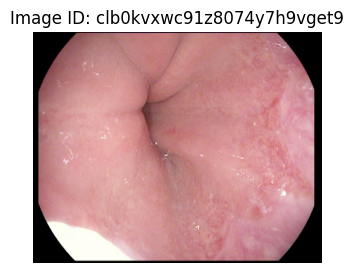

Question:
Which anatomical landmarks are visible in the image?
--------------------------------------------------------------------------------
Detailed Explanation (exp_ans):
Evidence of the z-line is visible in the image, appearing as a subtle transition in the pink and reddish-pink tissue, particularly noticeable in the lower and right areas of the view inside the tube-like structure.
--------------------------------------------------------------------------------


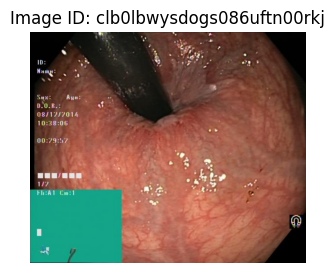

Question:
In which regions of the image is the instrument located?
--------------------------------------------------------------------------------
Detailed Explanation (exp_ans):
The instrument, a tube, is visible in the upper-central and upper-left areas of the image. It appears as a dark, oval-shaped area that curves inward against the reddish-pink surface.
--------------------------------------------------------------------------------


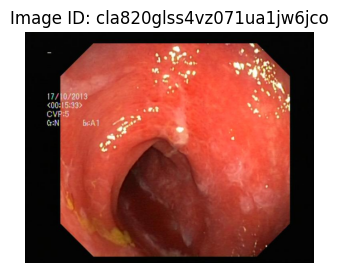

Question:
Which anatomical landmarks are visible in the image?
--------------------------------------------------------------------------------
Detailed Explanation (exp_ans):
Anatomical landmarks, specifically the cecum, are visible in the central and lower-left regions of the image. These areas appear as darker, somewhat unevenly textured openings within the predominantly reddish-pink tissue.
--------------------------------------------------------------------------------


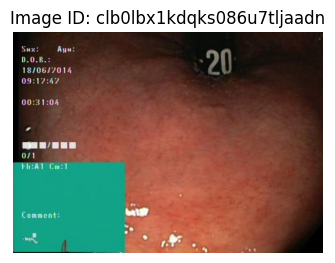

Question:
Are there any green or black box artifacts present?
--------------------------------------------------------------------------------
Detailed Explanation (exp_ans):
box artifacts are observed in the image. A large, bright teal-colored rectangle is present in the lower left corner, and a dark blurry shape obscures part of the upper right area.
--------------------------------------------------------------------------------


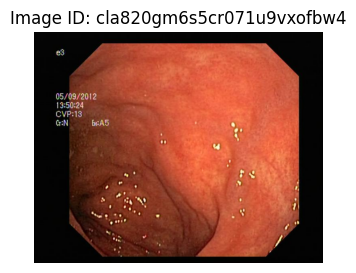

Question:
Where are the areas of abnormality located in the image?
--------------------------------------------------------------------------------
Detailed Explanation (exp_ans):
The areas of abnormality, indicative of ulcerative colitis, are distributed across multiple regions of the image, including the center, upper, and lower quadrants. These areas appear as a reddish-pink, wrinkled, and shiny surface with numerous small, yellowish-white speckles scattered throughout, and some larger, lighter-colored rounded shapes in the upper regions.
--------------------------------------------------------------------------------


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

original_csv = '../data/deprecated/vqa_exp_v2.csv'
IMAGES_DIR = '../data/images'

try:
    # We randomly grab or just take the first 5 samples
    df_orig = pd.read_csv(original_csv).head(5)
    
    for idx, row in df_orig.iterrows():
        img_id = str(row['img_id'])
        img_path = os.path.join(IMAGES_DIR, f"{img_id}.jpg")
        
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            fig, ax = plt.subplots(1, 1, figsize=(4, 3))
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(f"Image ID: {img_id}")
            plt.show()

            print("Question:")
            print(row['question'])
            print("-" * 80)
            print("Detailed Explanation (exp_ans):")
            print(row['exp_ans'])
            print("-" * 80)
        else:
            print(f"Image {img_id}.jpg not found.")
            
except Exception as e:
    print(f"Could not load the original CSV file: {e}")

## 2. Visualizing Masks Overlaid on Images

To solve the hallucination, we pivot to grounded visual descriptions. We load the original images and their corresponding masks (e.g., polyp, instrument, GradCAM), and overlay contours and bounding boxes. This explicitly forces the API vision model to look at the marked area.

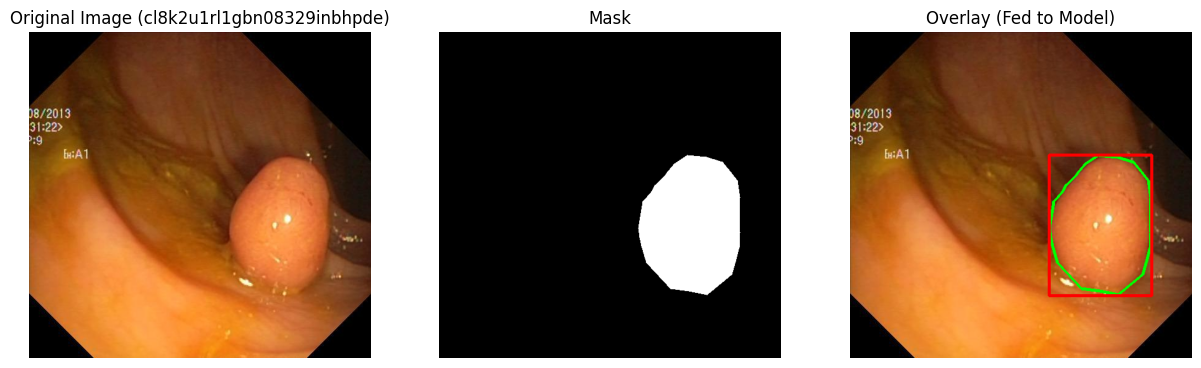

In [8]:
import glob

DATA_DIR = '../data'
masks = glob.glob(os.path.join(DATA_DIR, "polyp_masks", "*.jpg"))

if masks:
    MASK_PATH = masks[0]
    img_id = os.path.basename(MASK_PATH).split('.')[0]
    IMG_PATH = os.path.join(IMAGES_DIR, f"{img_id}.jpg")

    if os.path.exists(IMG_PATH) and os.path.exists(MASK_PATH):
        img = cv2.imread(IMG_PATH)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)
        _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        overlay = img.copy()
        for c in contours:
            cv2.drawContours(overlay, [c], -1, (0, 255, 0), thickness=3) # Green contour
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(overlay, (x, y), (x + w, y + h), (255, 0, 0), thickness=3) # Red bounding box
            
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(img)
        ax[0].set_title(f'Original Image ({img_id})')
        ax[0].axis('off')
        
        ax[1].imshow(binary_mask, cmap='gray')
        ax[1].set_title('Mask')
        ax[1].axis('off')
        
        ax[2].imshow(overlay)
        ax[2].set_title('Overlay (Fed to Model)')
        ax[2].axis('off')
        plt.show()
    else:
        print("Image or Mask not found.")
else:
    print("No masks found in the expected directory.")

## 3. Constructing the Prompt

The prompt is heavily constrained. It provides the ROI type and specific guidance directly telling the model (Gemma 3 27B) what to focus on based on the category of the highlighted region.

In [9]:
ROI_TAXONOMY = {
    "polyp": ("Polyp", "polyp"),
    "z-line": ("Z-line", "landmark"),
    "instrument": ("Instrument", "instrument")
}

def build_user_prompt(roi_type):
    display_name, category = ROI_TAXONOMY.get(roi_type, ("Unknown", "unknown"))
    
    hints = {
        "polyp": "Focus on the shape of the marked structure — whether it is raised, flat, or has a stalk — and describe its surface color and texture.",
        "landmark": "Focus on the visible boundary or transition zone. Describe any color change or difference in surface texture.",
        "instrument": "Focus on the physical appearance of the object inside the marked region. Describe its shape, color, and surface material."
    }
    
    system_prompt = """You are a visual description assistant for gastrointestinal endoscopy images.
You will be given an endoscopy image with a bounding box and contour drawn around a region of interest (ROI).
Write a short visual description of what is visible inside the marked region.
- Maximum 2 sentences.
- Use plain language — no medical or clinical terms.
- CRITICAL: Start directly with the visual description."""

    user_prompt = f"{system_prompt}\n\nROI type: {category.capitalize()}\nROI name: {display_name}\n\n"
    user_prompt += "The bounding box and contour in the image mark the region of interest. "
    user_prompt += "Provide a direct visual description in 1–2 sentences without introductory filler.\n\n"
    user_prompt += hints.get(category, "")
    
    return user_prompt

print("-- Example Prompt sent to Gemini for a Polyp --\n")
print(build_user_prompt('polyp'))

-- Example Prompt sent to Gemini for a Polyp --

You are a visual description assistant for gastrointestinal endoscopy images.
You will be given an endoscopy image with a bounding box and contour drawn around a region of interest (ROI).
Write a short visual description of what is visible inside the marked region.
- Maximum 2 sentences.
- Use plain language — no medical or clinical terms.
- CRITICAL: Start directly with the visual description.

ROI type: Polyp
ROI name: Polyp

The bounding box and contour in the image mark the region of interest. Provide a direct visual description in 1–2 sentences without introductory filler.

Focus on the shape of the marked structure — whether it is raised, flat, or has a stalk — and describe its surface color and texture.


## 4. Viewing the Generated Samples

After running the generation script, the short captions generated by Gemini are saved alongside the corresponding mask logic. Here are 5 visual pairs showing the updated visual captions generated.

Displaying 5 Generated Short Captions based on ROIs:



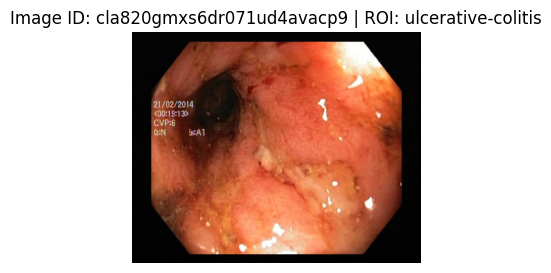

Visual Description (vis_des):
A reddish, uneven area with a bumpy texture is visible, and it appears somewhat raw or eroded. There are a few small, pale spots within this region, and the surface looks slightly raised compared to the surrounding tissue.
--------------------------------------------------------------------------------


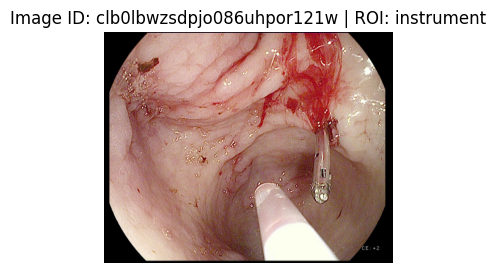

Visual Description (vis_des):
A shiny, silver tool with several small dark openings is visible, and it has a smooth, metallic surface. It appears to be made of plastic near the handle and is positioned against a wet, reddish tissue.
--------------------------------------------------------------------------------


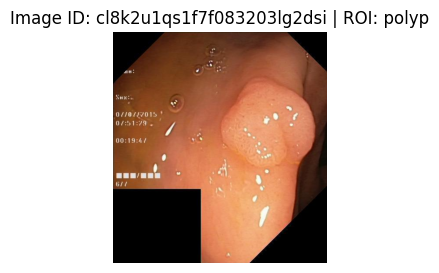

Visual Description (vis_des):
A somewhat rounded, bumpy area is visible, with a color similar to the surrounding tissue but appearing slightly paler. Small white spots are scattered across its surface, and it seems to rise up from the nearby lining.
--------------------------------------------------------------------------------


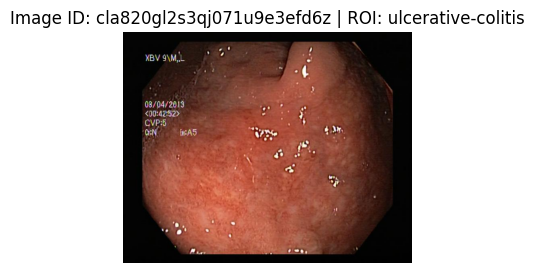

Visual Description (vis_des):
A reddish area with a bumpy texture is visible, and it appears somewhat raw or eroded in places. Small white spots are scattered throughout, and the surface isn’t smooth like the surrounding tissue.
--------------------------------------------------------------------------------


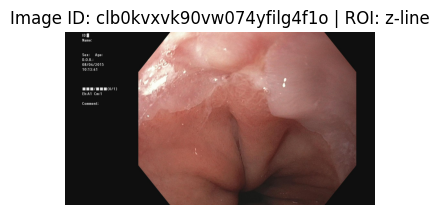

Visual Description (vis_des):
A slightly wavy, pinkish-purple line separates a smoother, paler area from a rougher, reddish-brown one. The line appears to create a distinct edge where the surfaces meet, with small bumps visible along it.
--------------------------------------------------------------------------------


In [10]:
csv_path = 'generated_captions.csv'

try:
    df_gen = pd.read_csv(csv_path).head(5)
    print(f"Displaying 5 Generated Short Captions based on ROIs:\n")
    
    for idx, row in df_gen.iterrows():
        img_id = str(row['img_id'])
        roi_type = row['roi_type']
        vis_des = row['vis_des']
        
        img_path = os.path.join(IMAGES_DIR, f"{img_id}.jpg")
        
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            fig, ax = plt.subplots(1, 1, figsize=(4, 3))
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(f"Image ID: {img_id} | ROI: {roi_type}")
            plt.show()
            
            print(f"Visual Description (vis_des):\n{vis_des}")
            print("-" * 80)
        else:
            print(f"Image {img_id}.jpg not found.")
            
except FileNotFoundError:
    print(f"Unable to find file: {csv_path}\nPlease run the generation script first.")